# Stage 4 · Features. Lahore house price model.

The model gets nine columns built from the 6,468 analysis rows: five carried as they are, a
locality label, and three engineered features against a ceiling of 30 (PLAN §8). The stage's
main finding concerns time. The 14.1% rise in median price per marla that EDA measured across
the window (D-55) runs between the two months that differ most in *what* was listed, so part
of it, probably a large part, is a change in mix rather than a change in prices (D-64).

**What this notebook is for.** Every choice in stage 4 is logged in
`project-log/decisions/05-features.md` as D-62 to D-67. This notebook rebuilds the evidence
behind them from the processed table, so each number in the log can be re-run rather than
taken on trust. The features themselves are built by `src/lhp/features.py`, which this
notebook imports and which stage 5, stage 6 and the estimator all share.

**Two standing constraints on the output.**

* **No listing rows, anywhere** (D-23). Nothing below prints a title, a description, a URL or
  one listing's values. Aggregates, distributions and place names only.
* **Every count is bounded where it is computed** (LESSONS L-26). A count cannot exceed its
  rows and a share cannot exceed 100%, and the assertion sits beside the expression.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

from lhp import features, viz
from lhp.clean import read_processed
from lhp.features import FeatureBuilder, LocalityEncoder, locality_label, log_price_per_marla

viz.use_house_style()
pd.set_option("display.max_rows", 60, "display.width", 120)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES = ROOT / "reports" / "figures"

df = read_processed(str(ROOT / "data" / "processed" / "listings.parquet"))
n = len(df)
assert n == df["fp_group_id"].nunique(), "the analysis set is not one row per group"
assert df["loc_society"].notna().all(), "a row without a society: D-63 should leave none"

print(f"analysis set  {n:,} rows x {df.shape[1]} columns")
print(f"window        {df['created_at'].min():%d %b %Y} to {df['created_at'].max():%d %b %Y}")

analysis set  6,468 rows x 42 columns
window        02 Sep 2023 to 14 Sep 2024


## 1 · The feature set

Thirteen columns went forward from EDA as candidates (D-51). Eight of them feed the nine
columns below, and every column names the finding it traces to. Five were dropped:
`loc_phase_num` because phase numbers are not ordered by price (D-40, D-62), and `loc_sector`,
`loc_block`, `loc_sub` and `loc_path` because the locality signal stops at the phase (D-62).

The nine barred columns of D-51 cannot reach the matrix: `features.py` refuses at import if
one is read or emitted, and the test suite fills them with random values to show the output
does not move.

In [2]:
trace = pd.DataFrame(
    [
        ("area_marla", "raw", "D-65", "size is read by the model within each location"),
        ("bedrooms", "raw", "D-66", "rooms vary within a plot size"),
        ("bathrooms", "raw", "D-66", "rooms vary within a plot size"),
        ("latitude_clean", "raw", "D-62", "lets thin levels borrow from neighbours"),
        ("longitude_clean", "raw", "D-62", "lets thin levels borrow from neighbours"),
        ("locality", "label", "D-62", "society plus phase, for stage 5's CatBoost comparison"),
        ("loc_log_ppm", "engineered", "D-62", "smoothed encoding of log price per marla"),
        ("months_since_start", "engineered", "D-64", "control for the drift and the mix shift"),
        ("lookup_log_price", "engineered", "D-65", "the baseline's estimate as one value"),
    ],
    columns=["column", "kind", "decision", "why it is there"],
).set_index("column")

assert tuple(trace.index) == features.FEATURE_COLUMNS, "the table and the module disagree"
assert not set(features.BARRED_COLUMNS) & set(features.FEATURE_COLUMNS)
trace

,kind,decision,why it is there
column,,,
area_marla,raw,D-65,size is read by the model within each location
bedrooms,raw,D-66,rooms vary within a plot size
bathrooms,raw,D-66,rooms vary within a plot size
latitude_clean,raw,D-62,lets thin levels borrow from neighbours
longitude_clean,raw,D-62,lets thin levels borrow from neighbours
locality,label,D-62,"society plus phase, for stage 5's CatBoost com..."
loc_log_ppm,engineered,D-62,smoothed encoding of log price per marla
months_since_start,engineered,D-64,control for the drift and the mix shift
lookup_log_price,engineered,D-65,the baseline's estimate as one value


## 2 · Time: the window's drift is tangled with a change in mix (D-64)

EDA measured median price per marla rising 14.1% from October 2023, the first complete month,
to August 2024, the last (D-55). Before treating that as the market's drift, it is worth
asking whether the same kind of house was being listed at both ends. The table below uses no
prices at all: only plot size and location, month by month.

In [3]:
pairs = zip(df["loc_society"].astype("object"), df["loc_phase"].astype("object"), strict=True)
level = pd.Series([locality_label(s, p) for s, p in pairs], index=df.index)
rows_per_level = level.value_counts()
major = set(rows_per_level[rows_per_level >= 100].index)          # D-50's major developments

month = df["created_at"].dt.tz_convert(None).dt.to_period("M")
mix = pd.DataFrame({
    "rows": df.groupby(month).size(),
    "median plot (marla)": df.groupby(month)["area_marla"].median(),
    "1 kanal or larger": df.groupby(month)["area_marla"].apply(lambda s: (s >= 20).mean()),
    "in DHA": df.groupby(month)["loc_society"].apply(lambda s: (s == "DHA").mean()),
    "in a major development": level.groupby(month).apply(lambda s: s.isin(major).mean()),
})
assert mix["rows"].sum() == n, "months lost rows"
shares = ["1 kanal or larger", "in DHA", "in a major development"]
assert (mix[shares] <= 1).all().all(), "a share above 100%"

formats = {"rows": "{:,.0f}", "median plot (marla)": "{:g}"} | {c: "{:.1%}" for c in shares}
mix.style.format(formats)

,rows,median plot (marla),1 kanal or larger,in DHA,in a major development
created_at,,,,,
2023-09,577,5,17.9%,11.4%,33.3%
2023-10,297,5,16.5%,6.1%,8.4%
2023-11,547,5,13.3%,4.6%,24.7%
2023-12,613,6,17.0%,9.6%,24.3%
2024-01,373,7.3,24.9%,12.1%,20.6%
2024-02,490,10,28.2%,20.4%,24.1%
2024-03,545,10,27.3%,31.6%,24.2%
2024-04,411,6,22.4%,7.5%,18.7%
2024-05,479,6,18.8%,3.1%,21.9%


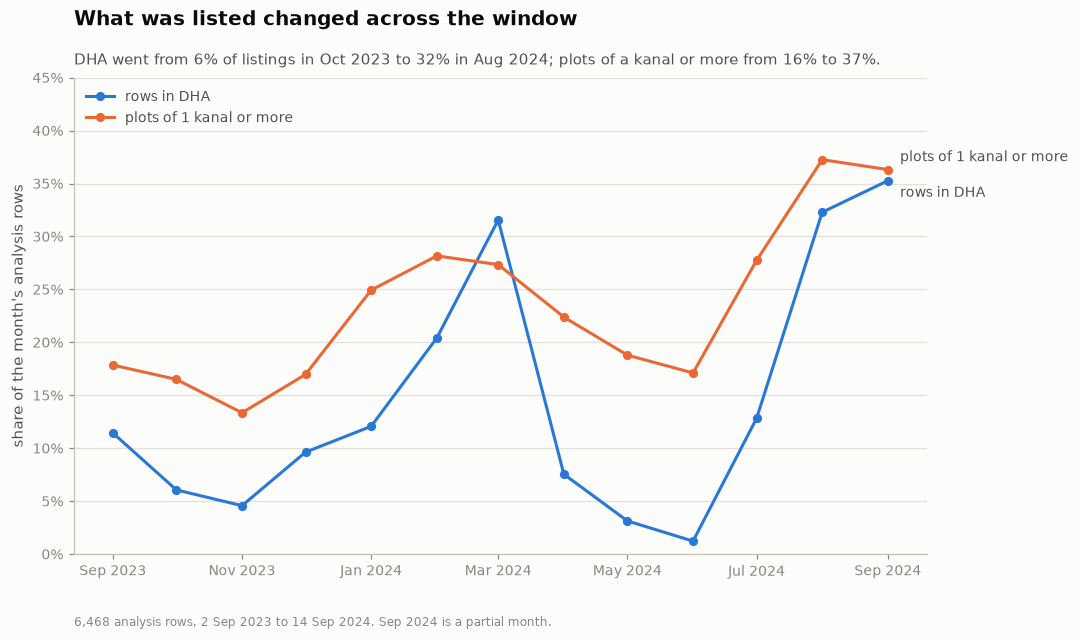

DHA rows in Feb, Mar, Aug and Sep 2024: 534 of 908


In [4]:
months = mix.index.to_timestamp()
fig, ax = plt.subplots()
# The two series end within a point of each other, so their end labels are nudged apart.
series = [("in DHA", "rows in DHA", -8), ("1 kanal or larger", "plots of 1 kanal or more", 8)]
for slot, (column, name, nudge) in enumerate(series):
    ax.plot(months, mix[column], color=viz.CATEGORICAL[slot], marker="o", markersize=5,
            linewidth=2, label=name)
    ax.annotate(name, (months[-1], mix[column].iloc[-1]), textcoords="offset points",
                xytext=(8, nudge), va="center", fontsize=9, color=viz.INK_SECONDARY)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 0.45)
ax.legend(loc="upper left", frameon=False)
oct23, aug24 = mix.loc[pd.Period("2023-10", "M")], mix.loc[pd.Period("2024-08", "M")]
viz.annotate(
    ax, title="What was listed changed across the window",
    subtitle=(f"DHA went from {oct23['in DHA']:.0%} of listings in Oct 2023 to "
              f"{aug24['in DHA']:.0%} in Aug 2024; plots of a kanal or more from "
              f"{oct23['1 kanal or larger']:.0%} to {aug24['1 kanal or larger']:.0%}."),
    ylabel="share of the month's analysis rows",
    source=f"{n:,} analysis rows, 2 Sep 2023 to 14 Sep 2024. Sep 2024 is a partial month.",
)
viz.save(fig, "08-listing-mix-by-month", directory=FIGURES)
plt.show()

dha_by_month = (df["loc_society"] == "DHA").groupby(month).sum()
busiest = [pd.Period(m, "M") for m in ("2024-02", "2024-03", "2024-08", "2024-09")]
in_busiest = int(dha_by_month.loc[busiest].sum())
assert in_busiest <= int(dha_by_month.sum()) <= n
print(f"DHA rows in Feb, Mar, Aug and Sep 2024: {in_busiest:,} of {int(dha_by_month.sum()):,}")

**Result.** October 2023 and August 2024, the two months that bound EDA's 14.1%, are the two
furthest apart in mix: DHA's share rose from 6.1% to 32.3% and plots of a kanal or more from
16.5% to 37.3%. Both price higher per marla (D-40, D-59). So an unknown but probably large part
of the 14.1% is a change in which houses were listed.

**What it decides.** `created_at` enters the model as months since the window opened (D-64),
as a control: with time beside location and size, the model can attribute a mix change to
location and size and a price change to time. Without it, DHA's locality encoding would absorb
whatever happened in the four months that hold most of its rows. When the estimator prices a
house, the feature is held at the training data's latest date, so it prices at September 2024
levels and says so.

**Why not the obvious alternatives.** Deflating prices to a common date with a monthly index
would build that index from exactly these confounded monthly medians. Feeding in today's date
changes nothing for a tree model, which treats every date past the last one it saw as the
last one, and it hides the assumption.

**What it changes downstream.** The README cannot quote 14.1% as the market's drift. Stage 7
reports the drift the model attributes to time instead (B-24, amended).

## 3 · Rooms carry information that size does not (D-66)

EDA profiled `bedrooms` and `bathrooms` (D-54) without recording a finding about them. The
question for stage 4 is whether they say anything that `area_marla` does not already say.

In [5]:
commonest = df["area_marla"].value_counts().head(6).index.sort_values()
spread = pd.DataFrame([
    {
        "plot (marla)": size,
        "rows": int((df["area_marla"] == size).sum()),
        "bedrooms p10": df.loc[df["area_marla"] == size, "bedrooms"].quantile(0.1),
        "median": df.loc[df["area_marla"] == size, "bedrooms"].median(),
        "p90": df.loc[df["area_marla"] == size, "bedrooms"].quantile(0.9),
    }
    for size in commonest
]).set_index("plot (marla)")
assert spread["rows"].sum() <= n

beds, baths = df["bedrooms"].astype(float), df["bathrooms"].astype(float)
gap = baths - beds
summary = pd.Series({
    "Spearman, bedrooms and area": beds.corr(df["area_marla"], method="spearman"),
    "Spearman, bathrooms and bedrooms": baths.corr(beds, method="spearman"),
    "rows with bathrooms equal to or one above bedrooms": gap.isin([0, 1]).mean(),
    "rows with fewer bathrooms than bedrooms": (gap < 0).mean(),
})
assert (summary.iloc[2:] <= 1).all()
display(spread.style.format("{:g}"))
summary.round(3).to_frame("value")

,rows,bedrooms p10,median,p90
plot (marla),,,,
3.000000,584,2,3,4
4.000000,298,3,3,4
5.000000,1545,3,4,5
10.000000,1163,4,5,6
20.000000,1019,5,5,6
40.000000,220,5,6,8


,value
"Spearman, bedrooms and area",0.704
"Spearman, bathrooms and bedrooms",0.878
rows with bathrooms equal to or one above bedrooms,0.908
rows with fewer bathrooms than bedrooms,0.066


**Result.** Room counts track size loosely (Spearman 0.70) and spread widely within a single
plot size: a 5 marla house has anywhere from 3 to 5 bedrooms between the 10th and 90th
percentile. They are the closest thing the data holds to covered area, which Ilaan does not
publish and which matters where houses go up rather than out (D-35).

**What it decides.** Both enter as they are. No ratio such as bedrooms per marla: the size by
rooms interaction sits on a small grid of standard plot sizes and room counts, which a tree
model splits directly, and no finding points at a ratio (D-66).

## 4 · The text columns hold almost nothing to extract (D-67)

`title` and `description` are text sources, never fed to a model as strings (D-51). The
question is whether extracting flags from them, a corner plot or a basement, would earn its
cost. The cell counts how often each signal appears. It prints no text.

In [6]:
title = df["title"].astype("object").fillna("").astype(str)
description = df["description"].astype("object").fillna("").astype(str)
empty = description.str.strip().eq("")
TEMPLATE = r"^\s*[\d.]+\s*(?:marla|kanal)\s+(?:house|home)\s+for\s+sale\s+in\s"
templated = title.str.match(TEMPLATE, case=False)

SIGNALS = {
    "corner": r"\bcorner\b",
    "park facing": r"park\s*fac|fac\w*\s+(?:the\s+)?park",
    "near park": r"near\s+(?:the\s+)?park",
    "boulevard": r"boulevard|\bblvd\b",
    "main road": r"main\s+road",
    "single storey": r"single\s*stor(?:e)?y",
    "double storey": r"double\s*stor(?:e)?y|2\s*stor(?:e)?y",
    "triple storey": r"triple\s*stor(?:e)?y|3\s*stor(?:e)?y",
    "basement": r"basement",
    "brand new": r"brand\s*new",
    "furnished": r"(?<!un)furnished",
    "Spanish style": r"spanish",
    "modern": r"\bmodern\b",
    "solar": r"\bsolar\b",
    "renovated": r"renovat",
    "old construction": r"\bold\s+(?:house|construction|built)",
    "road width in feet": r"\b\d{2,3}\s*(?:ft|feet|')\s*(?:wide\s+)?road",
    "owner built": r"owner\s*buil",
    "possession": r"possession",
    "installments": r"install?ment",
}
counts = {}
for name, pattern in SIGNALS.items():
    in_title = title.str.contains(pattern, case=False)
    in_description = description.str.contains(pattern, case=False)
    counts[name] = {"title": int(in_title.sum()), "description": int(in_description.sum()),
                    "either": int((in_title | in_description).sum())}
found = pd.DataFrame(counts).T.sort_values("either", ascending=False)
assert found["either"].max() <= n

print(f"descriptions empty or whitespace only   {int(empty.sum()):,} of {n:,} ({empty.mean():.1%})")
print(f"descriptions longer than 20 characters  {int((description.str.len() > 20).sum()):,}")
print(f"titles following the listing template   {int(templated.sum()):,} ({templated.mean():.1%})")
found.assign(**{"either %": lambda t: (100 * t["either"] / n).round(1)})

descriptions empty or whitespace only   6,354 of 6,468 (98.2%)
descriptions longer than 20 characters  101
titles following the listing template   6,082 (94.0%)


,title,description,either,either %
brand new,1,35,35,0.5
furnished,32,6,35,0.5
boulevard,14,0,14,0.2
modern,0,13,13,0.2
basement,0,8,8,0.1
main road,1,5,6,0.1
corner,0,5,5,0.1
double storey,0,5,5,0.1
owner built,0,5,5,0.1
Spanish style,1,5,5,0.1


**Result.** The descriptions are empty at source on 98.2% of rows: three sampled pages from
the local cache carry an empty description field, so sellers wrote nothing and the parser is
not losing text. 94.0% of titles follow one template whose area and place are already
extracted. The commonest signal appears on 35 rows, 0.5% of the set.

**What it decides.** Nothing is extracted (D-67). A flag on 0.5% of rows cannot carry weight,
and an unmentioned corner plot would be recorded as not a corner, so a flag would measure the
advert's wording rather than the house. While checking, 11 descriptions turned out to hold an
unresolved pointer into the page data instead of text; they are logged as B-25 and not fixed,
since nothing reads the column.

## 5 · The locality encoding at work (D-62)

Locality is the strongest price signal and it arrives as 442 levels, society plus phase, over
6,468 rows. 359 of those levels hold fewer than 20 rows. Each level is encoded as its average
log price per marla, pulled toward its society's average in proportion to how few rows it has,
and the society's toward the city's. The weight on a level's own average is n / (n + 20).

The cell fits the encoder once on every row, for illustration only. In training, stage 5 fits
it inside each fold and gives each training row a value computed without its own price
(`FeatureBuilder.fit_transform`). The example levels are chosen by row count alone, never by
price, and none holds fewer than five rows, so no single listing's price is shown.

In [7]:
lppm = log_price_per_marla(df["price"], df["area_marla"])
encoder = LocalityEncoder().fit(df["loc_society"], df["loc_phase"], lppm)
encoded = pd.Series(encoder.transform(df["loc_society"], df["loc_phase"]), index=df.index)

by_level = pd.DataFrame({"level": level, "society": df["loc_society"].astype("object"),
                         "lppm": lppm, "encoded": encoded})
table = by_level.groupby("level").agg(rows=("lppm", "size"), own=("lppm", "mean"),
                                      encoded=("encoded", "first"), society=("society", "first"))
assert table["rows"].sum() == n, "levels lost rows"

picks = []
for target in (5, 20, 100, table["rows"].max()):
    eligible = table[(table["rows"] >= 5) & ~table.index.isin(picks)]
    closest = (eligible["rows"] - target).abs()
    picks.append(closest[closest == closest.min()].index.sort_values()[0])

shown = table.loc[picks].assign(
    weight_on_own=lambda t: t["rows"] / (t["rows"] + encoder.smoothing),
    own_ppm=lambda t: np.exp(t["own"]),
    society_ppm=lambda t: np.exp(t["society"].map(encoder.society_)),
    encoded_ppm=lambda t: np.exp(t["encoded"]),
)[["rows", "weight_on_own", "own_ppm", "society_ppm", "encoded_ppm"]]
in_millions = {c: (lambda v: f"{v / 1e6:.2f}M") for c in ["own_ppm", "society_ppm", "encoded_ppm"]}
shown.style.format({"rows": "{:,.0f}", "weight_on_own": "{:.0%}"} | in_millions)

,rows,weight_on_own,own_ppm,society_ppm,encoded_ppm
level,,,,,
Al Ghani Garden | Phase 3,5,20%,2.04M,2.87M,2.68M
Al Ghani Garden,20,50%,2.43M,2.87M,2.64M
Ferozepur Road,101,83%,2.39M,2.57M,2.42M
DHA | Phase 6,260,93%,6.00M,4.90M,5.91M


**Reading the table.** Each encoded value sits between the level's own average and its
society's, closer to its own the more rows it has. The prices are geometric means per marla, the
back-transform of an average taken on the log scale. A five-row level is pulled a long way
toward its society; the largest level barely moves.

## 6 · The matrix

The whole matrix, built the way stage 5 will build it on a training fold. Stage 5 supplies the
real split key (B-23), which groups rows that might be one house; this cell uses one group per
row as a stand-in, so the shape and the checks are real and the grouping is not.

In [8]:
X = FeatureBuilder().fit_transform(df, groups=df["fp_group_id"].to_numpy())

assert X.shape == (n, len(features.FEATURE_COLUMNS)) and X.index.equals(df.index)
assert not set(features.BARRED_COLUMNS) & set(X.columns)
assert X["locality"].notna().all() and X["locality"].nunique() == len(table)
identity = X["lookup_log_price"] - (X["loc_log_ppm"] + np.log(df["area_marla"].astype(float)))
assert float(identity.abs().max()) < 1e-9, "the lookup estimate is not encoding plus log area"
assert lppm.min() <= X["loc_log_ppm"].min() and X["loc_log_ppm"].max() <= lppm.max()

print(f"matrix {X.shape[0]:,} rows x {X.shape[1]} columns")
print("missing values:", {c: int(v) for c, v in X.isna().sum().items() if v} or "none")
X.drop(columns="locality").describe().T[["count", "mean", "min", "50%", "max"]].round(2)

matrix 6,468 rows x 9 columns
missing values: {'latitude_clean': 62, 'longitude_clean': 62}


,count,mean,min,50%,max
area_marla,6468.0,11.752428,1.0,7.0,200.0
bedrooms,6468.0,4.297774,1.0,4.0,12.0
bathrooms,6468.0,4.728046,1.0,5.0,12.0
latitude_clean,6406.0,31.472727,31.252093,31.468963,31.733608
longitude_clean,6406.0,74.343236,74.057884,74.360219,74.542276
loc_log_ppm,6468.0,15.142198,14.384992,15.123731,15.601138
months_since_start,6468.0,6.477674,0.010065,6.789177,12.436556
lookup_log_price,6468.0,17.22782,14.612448,17.085091,20.835403


The only missing values are the 62 rows without a usable coordinate, which D-33 leaves missing
rather than imputed and which the tree models route on their own.

## 7 · What this stage decided

| Decision | What | The evidence | Logged as |
|---|---|---|---|
| Locality | Society plus phase, smoothed encoding fitted inside stage 5's folds, raw coordinates | Society plus phase scores 11.47% on the baseline against 12.24% for society alone, and the full path adds nothing (D-52) | D-62 |
| A parser fix | The one row with no society recovers it from its address | Its path read "DHA PHASE 6"; exactly one row changed on the re-run | D-63 |
| Time | Months since the window opened, held at the window's end for the estimator | The mix shift in section 2 | D-64, B-24 amended |
| Size | Area unbanded, plus the lookup estimate as one feature | The baseline alone scores 10.62% (D-47); size is meaningful only with location (D-59) | D-65 |
| Rooms | Bedrooms and bathrooms as they are, no ratios | Section 3 | D-66 |
| Text | Nothing extracted | Section 4 | D-67, B-25 |

Whether each feature earns its place is stage 5's question, answered by SHAP and ablation
against the §5.1 baseline. Stage 4 asked only whether each is justified by evidence.